# Parameter Estimation for REE Distribution Coefficients

This notebook uses `difflow.estimation` to recover the pH-dependent distribution
coefficients of the package's own PC88A correlation from *lab-style measurements* —
aqueous and organic concentrations out of an ICP-MS, not distribution coefficients
read off a plot.

## The model

The correlation `difflow_ree` evaluates is

$$\log_{10} D = a + b\,\mathrm{pH} + c\,\mathrm{pH}^2
  + d\left(\frac{1}{T} - \frac{1}{T_\mathrm{ref}}\right)
  + n\log_{10}\frac{[\mathrm{HA}]}{[\mathrm{HA}]_\mathrm{ref}}$$

At fixed temperature and fixed extractant concentration the last two terms drop out
and three parameters per element remain: $a$, $b$, $c$.

But the chemistry says more than that. Cation exchange with an acidic organophosphorus
extractant is

$$\mathrm{RE}^{3+} + 3\,\overline{(\mathrm{HA})_2}
  \;\rightleftharpoons\; \overline{\mathrm{RE}(\mathrm{HA}_2)_3} + 3\,\mathrm{H}^+$$

and taking $\log_{10}$ of the mass-action expression gives $b = 3$ **exactly** — the
number of protons released — with no quadratic term at all. The database was refit on
that basis, so every PC88A record carries $b = 3.0$ and $c = 0.0$.

## What this notebook asks

Given a realistic campaign, does the *data* agree? We fit a ladder of four models —
from the free three-parameter quadratic down to the one-parameter mass-action form —
and let AIC, BIC and the confidence intervals choose between them. Every conclusion
printed below is computed from the fit; none of it is asserted in prose.

In [1]:
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

jax.config.update("jax_enable_x64", True)

from difflow.estimation import Estimator, Experiment, check_identifiability
from difflow_ree.database import get_extractant
from difflow_ree.provenance import explain

## The answer we are trying to recover

The "true" parameters are not invented for this notebook — they are the coefficients
`difflow_ree` actually ships for PC88A, together with their provenance. Fitting
synthetic data generated from them is the honest version of a recovery test: we know
what the estimator should return, and we know where that number came from.

In [2]:
EXTRACTANT = "PC88A"
ELEMENTS = ("La", "Nd", "Dy")

ext = get_extractant(EXTRACTANT)
coeffs = ext.ph_coefficients

TRUE = {
    el: {"a": float(coeffs[el].a), "b": float(coeffs[el].b), "c": float(coeffs[el].c)}
    for el in ELEMENTS
}

PH_LO, PH_HI = ext.valid_ph_range
print(f"{EXTRACTANT}: valid pH range {PH_LO} - {PH_HI}, "
      f"[HA]_ref = {ext.reference_concentration} M\n")
print(f"{'element':<8}{'a':>10}{'b':>7}{'c':>7}   provenance of a")
print("-" * 78)
for el in ELEMENTS:
    p = explain("extractants", f"{EXTRACTANT}.ph_coefficients.{el}.a")
    src = p.citation or p.source_note or ""
    print(f"{el:<8}{TRUE[el]['a']:>10.4f}{TRUE[el]['b']:>7.2f}{TRUE[el]['c']:>7.2f}   "
          f"{p.cls:<9} {src[:44]}")

# The refit pinned the slope at the stoichiometric value and the quadratic term at
# zero. If that ever changes, this notebook's premise changes with it.
assert all(TRUE[el]["b"] == 3.0 for el in ELEMENTS), "b is no longer pinned at 3"
assert all(TRUE[el]["c"] == 0.0 for el in ELEMENTS), "c is no longer zero"

print(f"\nD = 1 crossovers (pH = -a/b):  "
      + ",  ".join(f"{el} {-TRUE[el]['a']/TRUE[el]['b']:.3f}" for el in ELEMENTS))

PC88A: valid pH range 0.1 - 2.5, [HA]_ref = 0.5 M

element          a      b      c   provenance of a
------------------------------------------------------------------------------
La         -4.0795   3.00   0.00   MEASURED  Tanaka, M.; Oki, T.; Koyama, K.; Narita, H. 
Nd         -3.0776   3.00   0.00   MEASURED  Tanaka, M.; Oki, T.; Koyama, K.; Narita, H. 
Dy         -0.3905   3.00   0.00   MEASURED  Tanaka, M.; Oki, T.; Koyama, K.; Narita, H. 

D = 1 crossovers (pH = -a/b):  La 1.360,  Nd 1.026,  Dy 0.130


## The campaign

Eight pH values inside PC88A's validated window, three replicates each, a single
equal-volume contact per run. The feed carries all three elements, so one ICP-MS run
on each phase returns six numbers per experiment.

Two pieces of realism matter for what comes out:

- **2 % relative analytical error**, which is typical for ICP-MS on a diluted REE
  sample.
- **A limit of quantitation.** With `b = 3` a distribution coefficient moves three
  decades per pH unit, so across the 2.1-unit campaign below `D` sweeps six orders of
  magnitude. At the top of that range the aqueous phase is stripped essentially bare
  and the measurement falls off the bottom of the calibration. Those observations are
  *censored* — dropped, not clipped, because a number below the LOQ is not a
  measurement.

In [3]:
PH_VALUES = np.array([0.2, 0.5, 0.8, 1.1, 1.4, 1.7, 2.0, 2.3])
N_REPLICATES = 3
C0 = 100.0          # mg/L of each element in the aqueous feed
V_AQ = V_ORG = 10.0  # mL, equal volumes
PHASE_RATIO = V_ORG / V_AQ
NOISE = 0.02        # 2 % relative, 1 sigma
LOQ = 0.01          # mg/L limit of quantitation (10 ppb)
SEED = 42

assert PH_VALUES.min() >= PH_LO and PH_VALUES.max() <= PH_HI, \
    "the campaign leaves the extractant's validated pH window"


def true_D(el, pH):
    t = TRUE[el]
    return 10.0 ** (t["a"] + t["b"] * pH + t["c"] * pH**2)


rng = np.random.default_rng(SEED)
runs = []
for pH in PH_VALUES:
    for rep in range(N_REPLICATES):
        row = {"pH": float(pH), "replicate": rep + 1}
        for el in ELEMENTS:
            D = true_D(el, pH)
            # C0 * V_aq = C_aq * V_aq + C_org * V_org  and  D = C_org / C_aq
            c_aq = C0 / (1.0 + D * PHASE_RATIO)
            c_org = D * c_aq
            row[f"C_{el}_aq"] = c_aq * (1.0 + NOISE * rng.standard_normal())
            row[f"C_{el}_org"] = c_org * (1.0 + NOISE * rng.standard_normal())
        runs.append(row)

data = pd.DataFrame(runs)
below_loq = {f"C_{el}_{ph}": int((data[f"C_{el}_{ph}"] < LOQ).sum())
             for el in ELEMENTS for ph in ("aq", "org")}

print(f"{len(data)} contacts = {len(PH_VALUES)} pH values x {N_REPLICATES} replicates")
print(f"pH {PH_VALUES.min():.1f} - {PH_VALUES.max():.1f}, "
      f"inside the validated window ({PH_LO}, {PH_HI})\n")
print(f"{'measurement':<14}{'below LOQ':>11}{'kept':>7}   D spanned")
print("-" * 60)
for el in ELEMENTS:
    for ph in ("aq", "org"):
        k = f"C_{el}_{ph}"
        print(f"{k:<14}{below_loq[k]:>11}{len(data) - below_loq[k]:>7}", end="")
        if ph == "aq":
            lo, hi = true_D(el, PH_VALUES.min()), true_D(el, PH_VALUES.max())
            print(f"   {lo:.3g} to {hi:.3g}")
        else:
            print()

_censored_el = [el for el in ELEMENTS if below_loq[f"C_{el}_aq"]]
print(f"\nCensored aqueous points belong to: {', '.join(_censored_el) or 'none'}")
print("Above the censoring pH the organic phase holds essentially all of the feed, "
      "so C_org\nsaturates at C0 and carries no information about D -- everything "
      "the fit can learn\nabout a strongly extracted element lives in C_aq.")

24 contacts = 8 pH values x 3 replicates
pH 0.2 - 2.3, inside the validated window (0.1, 2.5)

measurement     below LOQ   kept   D spanned
------------------------------------------------------------
C_La_aq                 0     24   0.000332 to 661
C_La_org                0     24
C_Nd_aq                 0     24   0.00333 to 6.64e+03
C_Nd_org                0     24
C_Dy_aq                 9     15   1.62 to 3.23e+06
C_Dy_org                0     24

Censored aqueous points belong to: Dy
Above the censoring pH the organic phase holds essentially all of the feed, so C_org
saturates at C0 and carries no information about D -- everything the fit can learn
about a strongly extracted element lives in C_aq.


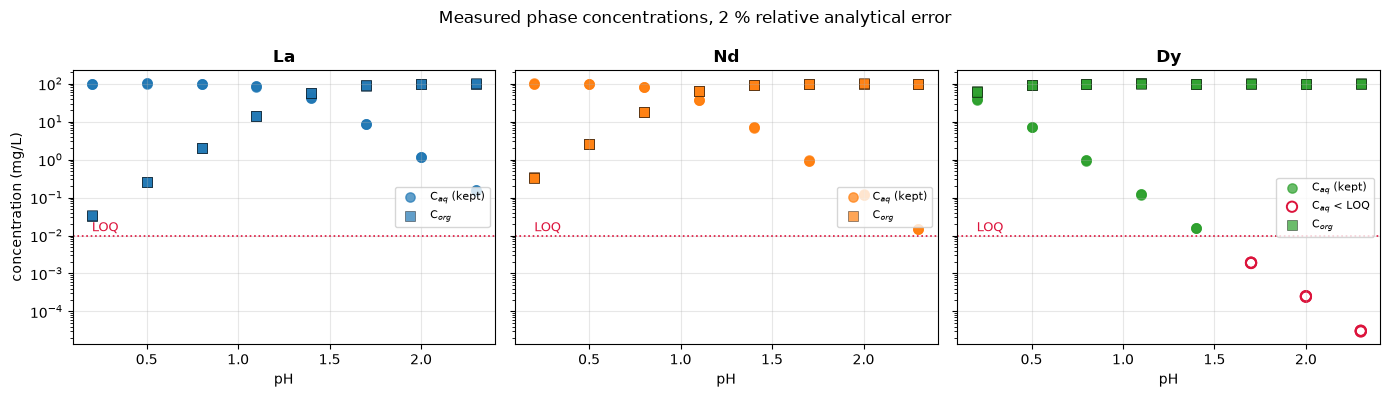

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = {"La": "#1f77b4", "Nd": "#ff7f0e", "Dy": "#2ca02c"}

for ax, el in zip(axes, ELEMENTS):
    aq, org = data[f"C_{el}_aq"], data[f"C_{el}_org"]
    keep_aq = aq >= LOQ
    ax.scatter(data["pH"][keep_aq], aq[keep_aq], s=45, alpha=0.7,
               color=colors[el], label="C$_{aq}$ (kept)")
    if (~keep_aq).any():
        ax.scatter(data["pH"][~keep_aq], aq[~keep_aq], s=55, facecolors="none",
                   edgecolors="crimson", linewidths=1.4, label="C$_{aq}$ < LOQ")
    ax.scatter(data["pH"], org, s=45, alpha=0.7, marker="s",
               color=colors[el], edgecolors="k", linewidths=0.4,
               label="C$_{org}$")
    ax.axhline(LOQ, color="crimson", ls=":", lw=1.2)
    ax.text(PH_VALUES.min(), LOQ * 1.3, "LOQ", color="crimson", fontsize=9)
    ax.set_yscale("log")
    ax.set_xlabel("pH")
    ax.set_title(el, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="center right")

axes[0].set_ylabel("concentration (mg/L)")
fig.suptitle("Measured phase concentrations, 2 % relative analytical error",
             fontsize=12)
plt.tight_layout()
plt.show()

## The model, and the ladder of models

The estimator predicts **what was measured** — the two phase concentrations — not the
distribution coefficient. `D` is an intermediate:

$$C_\mathrm{aq} = \frac{C_0}{1 + D\,(V_\mathrm{org}/V_\mathrm{aq})}, \qquad
  C_\mathrm{org} = D\,C_\mathrm{aq}$$

Fitting the raw concentrations rather than a derived `D` keeps the error model
honest: the 2 % is on the concentrations, and a ratio of two noisy numbers near the
LOQ has an error bar nothing like 2 %.

Four models share that structure and differ only in how $\log_{10} D$ is written:

| model | $\log_{10} D$ | parameters | what it assumes |
|---|---|---|---|
| `quadratic` | $a_i + b_i\,\mathrm{pH} + c_i\,\mathrm{pH}^2$ | 9 | nothing |
| `linear` | $a_i + b_i\,\mathrm{pH}$ | 6 | no curvature |
| `shared-slope` | $a_i + b\,\mathrm{pH}$ | 4 | one slope for all trivalent RE |
| `mass-action` | $a_i + 3\,\mathrm{pH}$ | 3 | that slope is the proton stoichiometry |

In [5]:
def make_model(form):
    'Return a model_fn(theta, exp) -> predicted concentrations.'
    def model_fn(theta, exp):
        pH = exp.inputs["pH"]
        ratio = exp.inputs["V_org"] / exp.inputs["V_aq"]
        out = {}
        for el in ELEMENTS:
            a = theta[f"a_{el}"]
            if form == "quadratic":
                log_D = a + theta[f"b_{el}"] * pH + theta[f"c_{el}"] * pH**2
            elif form == "linear":
                log_D = a + theta[f"b_{el}"] * pH
            elif form == "shared-slope":
                log_D = a + theta["b"] * pH
            elif form == "mass-action":
                log_D = a + 3.0 * pH
            else:
                raise ValueError(form)
            D = jnp.power(10.0, log_D)
            c_aq = exp.inputs[f"C0_{el}"] / (1.0 + D * ratio)
            out[f"C_{el}_aq"] = c_aq
            out[f"C_{el}_org"] = D * c_aq
        return out
    return model_fn


PARAM_NAMES = {
    "quadratic":    [f"{p}_{el}" for el in ELEMENTS for p in ("a", "b", "c")],
    "linear":       [f"{p}_{el}" for el in ELEMENTS for p in ("a", "b")],
    "shared-slope": [f"a_{el}" for el in ELEMENTS] + ["b"],
    "mass-action":  [f"a_{el}" for el in ELEMENTS],
}
INIT_BY_KIND = {"a": -2.0, "b": 2.0, "c": 0.0}


def theta_init_for(form):
    return {n: INIT_BY_KIND[n.split("_")[0]] for n in PARAM_NAMES[form]}


# One Experiment per contact. A measurement below the LOQ is simply absent from
# `observed`, so the objective never sees it -- clipping it to the LOQ would feed
# the fit a number the instrument did not produce.
experiments = []
for i, row in data.iterrows():
    observed, uncertainties = {}, {}
    for el in ELEMENTS:
        for phase in ("aq", "org"):
            key = f"C_{el}_{phase}"
            if row[key] >= LOQ:
                observed[key] = float(row[key])
                uncertainties[key] = NOISE * float(row[key])
    experiments.append(Experiment(
        inputs={"pH": float(row["pH"]), "V_aq": V_AQ, "V_org": V_ORG,
                **{f"C0_{el}": C0 for el in ELEMENTS}},
        observed=observed,
        uncertainties=uncertainties,
        name=f"pH{row['pH']:.1f}-rep{int(row['replicate'])}",
    ))

n_obs = sum(len(e.observed) for e in experiments)
print(f"{len(experiments)} experiments, {n_obs} surviving observations "
      f"({len(data) * 2 * len(ELEMENTS) - n_obs} censored)")
print(f"Widest model: {len(PARAM_NAMES['quadratic'])} parameters, "
      f"{n_obs - len(PARAM_NAMES['quadratic'])} degrees of freedom")

24 experiments, 135 surviving observations (9 censored)
Widest model: 9 parameters, 126 degrees of freedom


## Identifiability first

`difflow.estimation` states the order of operations plainly: before fitting anything,
ask whether the parameters can be told apart at all. If the sensitivity matrix is rank
deficient, some combination of parameters changes no prediction and no optimizer and
no experiment design can recover them individually.

The nine-parameter model is the one at risk: over a 2.1-unit pH span, $1$, $\mathrm{pH}$
and $\mathrm{pH}^2$ are strongly collinear.

In [6]:
report = check_identifiability(
    make_model("quadratic"),
    theta_init_for("quadratic"),
    experiments,
    PARAM_NAMES["quadratic"],
)

print(report.summary())
print(f"\nSingular values, largest to smallest:")
print("  " + "  ".join(f"{s:.3g}" for s in np.asarray(report.singular_values)))
print(f"\nFull column rank ({report.rank}/{report.n_params}), so the parameters are "
      f"formally identifiable.\nThe condition number of {report.condition_number:.1f} "
      f"is the warning: a formally identifiable\nmodel can still be a badly "
      f"conditioned one, and rank says nothing about precision.")

identifiable      : True
rank / parameters : 9 / 9
measurements      : 135
condition number  : 1456
rank gap          : inf
rank tolerance    : 1.238

singular values   : 6.153e+05, 3.282e+04, 2.664e+04, 2.086e+04, 4776, 3091, 1072, 663.3, 422.5

Singular values, largest to smallest:
  6.15e+05  3.28e+04  2.66e+04  2.09e+04  4.78e+03  3.09e+03  1.07e+03  663  422

Full column rank (9/9), so the parameters are formally identifiable.
The condition number of 1456.5 is the warning: a formally identifiable
model can still be a badly conditioned one, and rank says nothing about precision.


## Fit the widest model

Weighted least squares, with each residual divided by its own 2 % error bar.

In [7]:
fits = {}
for form in PARAM_NAMES:
    t0 = time.perf_counter()
    est = Estimator(make_model(form), PARAM_NAMES[form])
    res = est.fit(experiments, theta_init_for(form),
                  objective="wsse", method="L-BFGS-B")
    ci = est.confidence_intervals(res, experiments, objective="wsse")
    diag = est.diagnostics(res, experiments)
    fits[form] = dict(est=est, result=res, ci=ci, diag=diag,
                      seconds=time.perf_counter() - t0)
    assert res.converged, f"{form} did not converge: {res.message}"

# The confidence intervals must come from the objective the fit minimized. On
# concentrations spanning four decades the unweighted Hessian is set almost
# entirely by the ~100 mg/L points, and its standard errors are not the standard
# errors of a weighted fit -- so `objective="wsse"` here is not decoration.
print(fits["quadratic"]["est"].summary(
    fits["quadratic"]["result"], experiments, objective="wsse"))

Parameter Estimation Summary
Converged: True
Objective value: 89.6679
Iterations: 67

Parameters:
  Name                   Value      Std Err     CI Lower     CI Upper
  ---------------------------------------------------------------
  a_La                -4.08634   0.00367094      -4.0936     -4.07907
  b_La                 3.01545   0.00711008      3.00138      3.02952
  c_La             -0.00682296   0.00276548   -0.0122958  -0.00135014
  a_Nd                -3.08055   0.00360888     -3.08769     -3.07341
  b_Nd                 3.00389   0.00696791       2.9901      3.01768
  c_Nd            -0.000684853   0.00273237  -0.00609213   0.00472242
  a_Dy               -0.395415   0.00632989    -0.407941    -0.382888
  b_Dy                 3.00583    0.0168775      2.97243      3.03923
  c_Dy            -0.000285005   0.00987194   -0.0198213    0.0192513

Diagnostics:
  R-squared:     0.999246
  Adj R-squared: 0.999192
  RMSE:          1.20362
  AIC:           68.0399
  BIC:           94.

## Does the data want the quadratic term?

Two ways to ask. The individual $t$-statistic $c_i / \mathrm{se}(c_i)$ asks whether
each curvature term differs from zero. AIC and BIC ask whether carrying nine
parameters buys enough fit to pay for them.

They can disagree, and when they do the information criteria are the better guide:
with 135 observations, "significantly different from zero" and "large enough to
matter" are not the same question.

In [8]:
quad = fits["quadratic"]
print(f"{'element':<9}{'c':>10}{'se(c)':>9}{'t = c/se':>10}{'95% CI':>22}"
      f"   excludes 0?")
print("-" * 72)
n_flagged = 0
for el in ELEMENTS:
    k = f"c_{el}"
    c, se = quad["result"].theta_opt[k], quad["ci"].std_errors[k]
    lo, hi = quad["ci"].ci_lower[k], quad["ci"].ci_upper[k]
    excl = not (lo <= 0.0 <= hi)
    n_flagged += excl
    print(f"{el:<9}{c:>10.4f}{se:>9.4f}{c / se:>10.2f}"
          f"{f'[{lo:+.4f}, {hi:+.4f}]':>22}   {'yes' if excl else 'no'}")

p_any = 1.0 - 0.95 ** len(ELEMENTS)
print(f"\n{n_flagged} of {len(ELEMENTS)} quadratic terms exclude zero at the 5 % "
      f"level.\nThe terms are truly zero, and a 5 % test applied {len(ELEMENTS)} "
      f"times flags at least one of them\n{100 * p_any:.0f} % of the time "
      f"({1 / p_any:.1f} to 1 against), so this says nothing about the chemistry.")

# Why the quadratic model is imprecise: a, b and c trade off against each other.
names = PARAM_NAMES["quadratic"]
corr = np.asarray(quad["ci"].correlation)
print(f"\nParameter correlations inside the quadratic model:")
for el in ELEMENTS:
    ia, ib, ic = (names.index(f"{p}_{el}") for p in ("a", "b", "c"))
    print(f"  {el}:  corr(a,b) = {corr[ia, ib]:+.3f}   "
          f"corr(b,c) = {corr[ib, ic]:+.3f}   corr(a,c) = {corr[ia, ic]:+.3f}")
print("A slope and a curvature measured over one narrow pH window are nearly the "
      "same\nparameter, which is what the condition number above was reporting.")

element           c    se(c)  t = c/se                95% CI   excludes 0?
------------------------------------------------------------------------
La          -0.0068   0.0028     -2.47    [-0.0123, -0.0014]   yes
Nd          -0.0007   0.0027     -0.25    [-0.0061, +0.0047]   no
Dy          -0.0003   0.0099     -0.03    [-0.0198, +0.0193]   no

1 of 3 quadratic terms exclude zero at the 5 % level.
The terms are truly zero, and a 5 % test applied 3 times flags at least one of them
14 % of the time (7.0 to 1 against), so this says nothing about the chemistry.

Parameter correlations inside the quadratic model:
  La:  corr(a,b) = -0.890   corr(b,c) = -0.976   corr(a,c) = +0.794
  Nd:  corr(a,b) = -0.876   corr(b,c) = -0.975   corr(a,c) = +0.772
  Dy:  corr(a,b) = -0.925   corr(b,c) = -0.977   corr(a,c) = +0.838
A slope and a curvature measured over one narrow pH window are nearly the same
parameter, which is what the condition number above was reporting.


## The ladder

Now compare all four models on the same 135 observations.

In [9]:
ladder = pd.DataFrame([
    {
        "model": form,
        "params": f["diag"].n_params,
        "wSSE": f["result"].objective_value,
        "RMSE (mg/L)": f["diag"].rmse,
        "R2": f["diag"].r_squared,
        "AIC": f["diag"].aic,
        "BIC": f["diag"].bic,
        "se(a_La)": f["ci"].std_errors["a_La"],
    }
    for form, f in fits.items()
])
with pd.option_context("display.width", None, "display.precision", 4):
    print(ladder.to_string(index=False))

best_aic = ladder.loc[ladder["AIC"].idxmin(), "model"]
best_bic = ladder.loc[ladder["BIC"].idxmin(), "model"]
rmse_spread = ladder["RMSE (mg/L)"].max() - ladder["RMSE (mg/L)"].min()
se_ratio = (ladder["se(a_La)"].max() / ladder["se(a_La)"].min())

print(f"\nLowest AIC: {best_aic}.  Lowest BIC: {best_bic}.")
print(f"RMSE across the whole ladder spans {rmse_spread:.4f} mg/L "
      f"({100 * rmse_spread / ladder['RMSE (mg/L)'].min():.2f} % of the smallest) --")
print(f"the six extra parameters buy essentially no fit, and cost a factor of "
      f"{se_ratio:.1f} in the\nprecision of a_La.")

assert best_aic == "mass-action" and best_bic == "mass-action", (
    "the information criteria no longer pick the mass-action model; rewrite the "
    "discussion rather than the assertion")

# Is the freely fitted shared slope consistent with the stoichiometric 3?
b_hat = fits["shared-slope"]["result"].theta_opt["b"]
b_se = fits["shared-slope"]["ci"].std_errors["b"]
b_lo = fits["shared-slope"]["ci"].ci_lower["b"]
b_hi = fits["shared-slope"]["ci"].ci_upper["b"]
print(f"\nShared slope fitted freely: b = {b_hat:.4f} +- {b_se:.4f}, "
      f"95% CI [{b_lo:.4f}, {b_hi:.4f}]")
print(f"Mass action predicts exactly 3 (three protons released per RE3+): "
      f"{abs(b_hat - 3.0) / b_se:.2f} standard errors away, "
      f"{'inside' if b_lo <= 3.0 <= b_hi else 'outside'} the 95 % interval.")

       model  params    wSSE  RMSE (mg/L)     R2     AIC     BIC  se(a_La)
   quadratic       9 89.6679       1.2036 0.9992 68.0399 94.1873    0.0037
      linear       6 91.8559       1.2086 0.9992 63.1508 80.5825    0.0022
shared-slope       4 93.5645       1.2084 0.9992 59.1187 70.7398    0.0017
 mass-action       3 93.7326       1.2084 0.9992 57.1164 65.8322    0.0011

Lowest AIC: mass-action.  Lowest BIC: mass-action.
RMSE across the whole ladder spans 0.0050 mg/L (0.41 % of the smallest) --
the six extra parameters buy essentially no fit, and cost a factor of 3.3 in the
precision of a_La.

Shared slope fitted freely: b = 3.0007 +- 0.0011, 95% CI [2.9986, 3.0028]
Mass action predicts exactly 3 (three protons released per RE3+): 0.69 standard errors away, inside the 95 % interval.


## Recovered intercepts against the database

With the slope pinned, one parameter per element is left, and it is the one the
database tabulates. This is the recovery test: does the estimator return the
coefficients the data were generated from?

In [10]:
final = fits["mass-action"]
rows = []
for el in ELEMENTS:
    k = f"a_{el}"
    rows.append({
        "element": el,
        "database a": TRUE[el]["a"],
        "fitted a": final["result"].theta_opt[k],
        "error": final["result"].theta_opt[k] - TRUE[el]["a"],
        "std err": final["ci"].std_errors[k],
        "CI lower": final["ci"].ci_lower[k],
        "CI upper": final["ci"].ci_upper[k],
    })
recovery = pd.DataFrame(rows)
recovery["in CI"] = ((recovery["database a"] >= recovery["CI lower"])
                     & (recovery["database a"] <= recovery["CI upper"]))
recovery["|error| / se"] = (recovery["error"].abs() / recovery["std err"])

with pd.option_context("display.width", None, "display.precision", 4):
    print(recovery.to_string(index=False))

n_in = int(recovery["in CI"].sum())
print(f"\n{n_in}/{len(recovery)} database values inside the 95 % interval; "
      f"largest miss {recovery['|error| / se'].max():.2f} standard errors.")
print(f"Largest absolute error in a: {recovery['error'].abs().max():.4f} log units, "
      f"which is a factor of\n{10 ** recovery['error'].abs().max():.4f} in D.")

assert n_in == len(recovery), (
    "the estimator no longer recovers the tabulated intercepts -- investigate "
    "before trusting anything below")

element  database a  fitted a       error  std err  CI lower  CI upper  in CI  |error| / se
     La     -4.0795   -4.0812 -1.6923e-03   0.0011   -4.0834   -4.0790   True        1.5012
     Nd     -3.0776   -3.0771  5.3992e-04   0.0011   -3.0793   -3.0748   True        0.4808
     Dy     -0.3905   -0.3906 -7.4513e-05   0.0014   -0.3934   -0.3878   True        0.0522

3/3 database values inside the 95 % interval; largest miss 1.50 standard errors.
Largest absolute error in a: 0.0017 log units, which is a factor of
1.0039 in D.


## Bootstrap

The confidence intervals above come from the Fisher information: a quadratic
approximation to the objective at the optimum. Resampling the experiments makes no
such approximation, so agreement between the two is evidence the approximation holds
here.

In [11]:
t0 = time.perf_counter()
boot = final["est"].bootstrap(
    final["result"], experiments, n_bootstrap=200,
    method="nonparametric", seed=SEED, objective="wsse",
)
print(f"{boot.n_bootstrap} {boot.method} resamples in "
      f"{time.perf_counter() - t0:.1f} s\n")

print(f"{'parameter':<11}{'fitted':>10}{'Fisher se':>12}{'bootstrap se':>14}"
      f"{'ratio':>8}")
print("-" * 55)
ratios = []
for el in ELEMENTS:
    k = f"a_{el}"
    fse, bse = final["ci"].std_errors[k], boot.std[k]
    ratios.append(bse / fse)
    print(f"{k:<11}{final['result'].theta_opt[k]:>10.4f}{fse:>12.5f}"
          f"{bse:>14.5f}{bse / fse:>8.2f}")

print(f"\nBootstrap / Fisher standard errors span "
      f"{min(ratios):.2f} to {max(ratios):.2f}.")
print(f"Within a factor of {max(max(ratios), 1 / min(ratios)):.1f} of each "
      f"other, so the quadratic approximation the Fisher\nintervals rest on is "
      f"not what sets the reported precision. Exact agreement was never\n"
      f"expected: the nonparametric bootstrap resamples {len(experiments)} whole "
      f"experiments -- a coarse unit,\ncarrying up to {2 * len(ELEMENTS)} "
      f"correlated measurements each -- while the Fisher interval treats\nthe "
      f"declared {100 * NOISE:.0f} % uncertainties as exact.")
print("\nNote the `objective=\"wsse\"` above. The bootstrap refits, and it must "
      "refit the SAME\nobjective the fit minimized. Left on the unweighted "
      "default it returns the sampling\ndistribution of a different estimator, "
      "and the disagreement that produces looks like a\nbroken linearization "
      "rather than the bookkeeping error it is.")

200 nonparametric resamples in 248.9 s

parameter      fitted   Fisher se  bootstrap se   ratio
-------------------------------------------------------
a_La          -4.0812     0.00113       0.00156    1.38
a_Nd          -3.0771     0.00112       0.00128    1.14
a_Dy          -0.3906     0.00143       0.00208    1.46

Bootstrap / Fisher standard errors span 1.14 to 1.46.
Within a factor of 1.5 of each other, so the quadratic approximation the Fisher
intervals rest on is not what sets the reported precision. Exact agreement was never
expected: the nonparametric bootstrap resamples 24 whole experiments -- a coarse unit,
carrying up to 6 correlated measurements each -- while the Fisher interval treats
the declared 2 % uncertainties as exact.

Note the `objective="wsse"` above. The bootstrap refits, and it must refit the SAME
objective the fit minimized. Left on the unweighted default it returns the sampling
distribution of a different estimator, and the disagreement that produces looks l

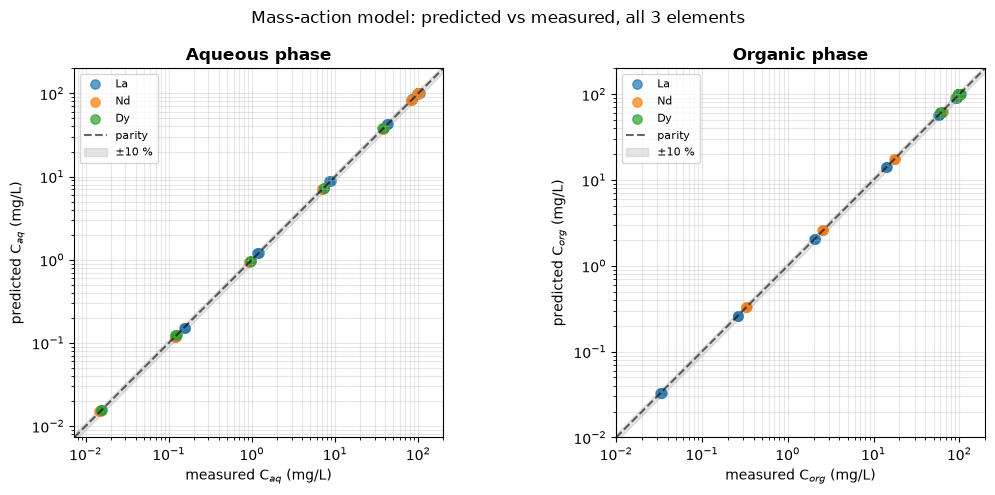

Relative deviation over all 135 observations: median 1.07 %, 95th percentile 3.04 %, max 5.51 %
Inside the +-10 % band: 100.0 % of points.  The measurement error
was 2 % (1 sigma), so a residual spread of that size is the data, not the model.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
model_fn = make_model("mass-action")
theta_hat = final["result"].theta_opt

within = {}
for ax, phase, title in zip(axes, ("aq", "org"),
                            ("Aqueous phase", "Organic phase")):
    all_rel = []
    for el in ELEMENTS:
        obs, pred = [], []
        for exp in experiments:
            key = f"C_{el}_{phase}"
            if key in exp.observed:
                obs.append(exp.observed[key])
                pred.append(float(model_fn(theta_hat, exp)[key]))
        ax.scatter(obs, pred, s=45, alpha=0.7, color=colors[el], label=el)
        all_rel += [abs(p / o - 1.0) for o, p in zip(obs, pred)]
    within[phase] = all_rel

    lo = min(min(exp.observed[f"C_{el}_{phase}"]
                 for exp in experiments for el in ELEMENTS
                 if f"C_{el}_{phase}" in exp.observed) * 0.5, LOQ)
    hi = C0 * 2.0
    lims = [lo, hi]
    ax.plot(lims, lims, "k--", lw=1.5, alpha=0.6, label="parity")
    ax.fill_between(lims, [0.9 * x for x in lims], [1.1 * x for x in lims],
                    color="gray", alpha=0.2, label="$\\pm$10 %")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel(f"measured C$_{{{phase}}}$ (mg/L)")
    ax.set_ylabel(f"predicted C$_{{{phase}}}$ (mg/L)")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Mass-action model: predicted vs measured, all 3 elements",
             fontsize=12)
plt.tight_layout()
plt.show()

rel = np.array(within["aq"] + within["org"])
print(f"Relative deviation over all {rel.size} observations: "
      f"median {100 * np.median(rel):.2f} %, 95th percentile "
      f"{100 * np.percentile(rel, 95):.2f} %, max {100 * rel.max():.2f} %")
print(f"Inside the +-10 % band: {100 * (rel <= 0.10).mean():.1f} % of points.  "
      f"The measurement error\nwas {100 * NOISE:.0f} % (1 sigma), so a residual "
      f"spread of that size is the data, not the model.")

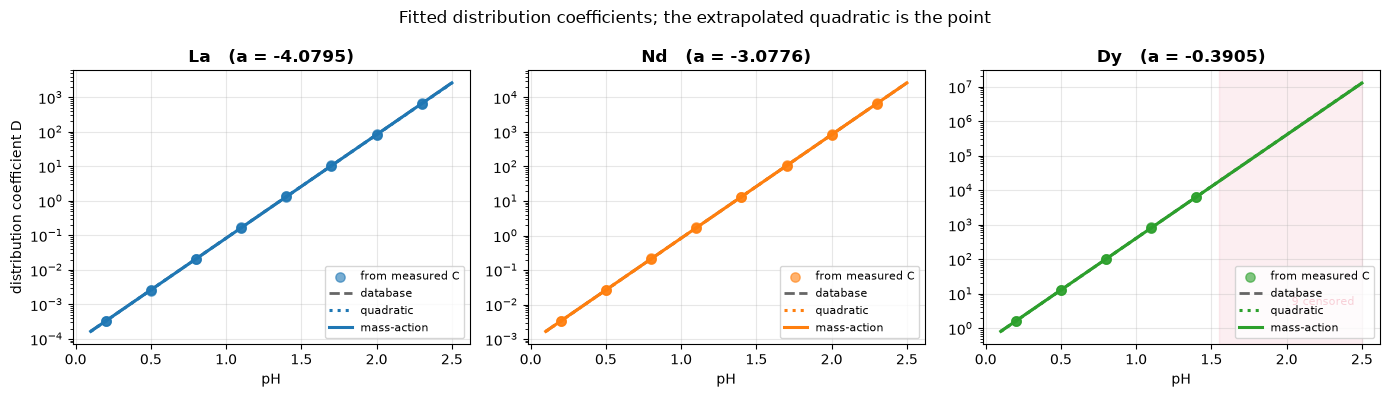

The two curves are indistinguishable to the eye everywhere, including outside the data.
The difference is in what they claim to know. 95 % band on D (multiplicative factor):

                pH 0.1                    pH 2.5          
          quadratic  mass-action    quadratic  mass-action
----------------------------------------------------------
La          x/1.014      x/1.005      x/1.017      x/1.005
Nd          x/1.014      x/1.005      x/1.017      x/1.005
Dy          x/1.022      x/1.006      x/1.127      x/1.006

At the far edge of the window the quadratic model's 95 % band on D is up to 20x wider
for exactly the same data -- worst for Dy, whose usable measurements stop at pH 1.4
and leave 1.1 pH units of pure extrapolation. That is the price of the two parameters
the stoichiometry already fixed.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
pH_fine = np.linspace(PH_LO, PH_HI, 200)

for ax, el in zip(axes, ELEMENTS):
    # D implied by the measurements, where both phases were quantifiable
    ph_obs, d_obs = [], []
    for exp in experiments:
        ka, ko = f"C_{el}_aq", f"C_{el}_org"
        if ka in exp.observed and ko in exp.observed:
            ph_obs.append(exp.inputs["pH"])
            d_obs.append(exp.observed[ko] / exp.observed[ka])
    ax.scatter(ph_obs, d_obs, s=45, alpha=0.6, color=colors[el], zorder=3,
               label="from measured C")

    ax.plot(pH_fine, [true_D(el, p) for p in pH_fine], "k--", lw=2, alpha=0.6,
            zorder=2, label="database")
    for form, style in (("quadratic", ":"), ("mass-action", "-")):
        th = fits[form]["result"].theta_opt
        a = th[f"a_{el}"]
        b = th.get(f"b_{el}", th.get("b", 3.0))
        c = th.get(f"c_{el}", 0.0)
        ax.plot(pH_fine, 10.0 ** (a + b * pH_fine + c * pH_fine**2),
                style, color=colors[el], lw=2.2, zorder=4, label=form)

    n_cens = len(data) - len(ph_obs)
    if n_cens:
        ax.axvspan(min(p for p in PH_VALUES if p not in ph_obs) - 0.15, PH_HI,
                   color="crimson", alpha=0.07, zorder=0)
        ax.text(PH_HI - 0.05, min(d_obs) * 3, f"{n_cens} censored",
                color="crimson", fontsize=8, ha="right")

    ax.set_yscale("log")
    ax.set_xlabel("pH")
    ax.set_title(f"{el}   (a = {TRUE[el]['a']:.4f})", fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="lower right")

axes[0].set_ylabel("distribution coefficient D")
fig.suptitle("Fitted distribution coefficients; the extrapolated quadratic is "
             "the point", fontsize=12)
plt.tight_layout()
plt.show()

# The two curves lie on top of each other. What separates them is not where they
# go but how well they are known when they get there: propagate the parameter
# covariance to log10(D) at the edges of the validated window.
def logD_sigma(form, el, pH):
    names = PARAM_NAMES[form]
    cov = np.asarray(fits[form]["ci"].covariance)
    g = np.zeros(len(names))
    g[names.index(f"a_{el}")] = 1.0
    if f"b_{el}" in names:
        g[names.index(f"b_{el}")] = pH
    elif "b" in names:
        g[names.index("b")] = pH
    if f"c_{el}" in names:
        g[names.index(f"c_{el}")] = pH**2
    return float(np.sqrt(g @ cov @ g))


print("The two curves are indistinguishable to the eye everywhere, including "
      "outside the data.")
print("The difference is in what they claim to know. 95 % band on D "
      "(multiplicative factor):\n")
print(f"{'':<6}{'pH ' + str(PH_LO):^26}{'pH ' + str(PH_HI):^26}")
print(f"{'':<6}{'quadratic':>13}{'mass-action':>13}"
      f"{'quadratic':>13}{'mass-action':>13}")
print("-" * 58)
worst = 0.0
for el in ELEMENTS:
    cells_ = []
    for p in (PH_LO, PH_HI):
        for form in ("quadratic", "mass-action"):
            f = 10.0 ** (1.96 * logD_sigma(form, el, p))
            cells_.append(f"x/{f:.3f}")
        worst = max(worst, (10.0 ** (1.96 * logD_sigma("quadratic", el, p)) - 1)
                    / (10.0 ** (1.96 * logD_sigma("mass-action", el, p)) - 1))
    print(f"{el:<6}" + "".join(f"{c:>13}" for c in cells_))
_reach = {el: max((e.inputs["pH"] for e in experiments
                   if f"C_{el}_aq" in e.observed), default=float("nan"))
          for el in ELEMENTS}
_worst_el = min(_reach, key=_reach.get)
print(f"\nAt the far edge of the window the quadratic model's 95 % band on D is up "
      f"to {worst:.0f}x wider\nfor exactly the same data -- worst for {_worst_el}, "
      f"whose usable measurements stop at pH {_reach[_worst_el]:.1f}\nand leave "
      f"{PH_HI - _reach[_worst_el]:.1f} pH units of pure extrapolation. That is the "
      f"price of the two parameters\nthe stoichiometry already fixed.")

## Diagnostics

The interpretation below is printed from the numbers, not written next to them.

In [14]:
diag = final["diag"]
print("Mass-action model diagnostics")
print("=" * 62)
print(f"R^2:              {diag.r_squared:.6f}")
print(f"Adjusted R^2:     {diag.r_squared_adj:.6f}")
print(f"RMSE:             {diag.rmse:.4f} mg/L")
print(f"AIC / BIC:        {diag.aic:.2f} / {diag.bic:.2f}")
print(f"N observations:   {diag.n_obs}  "
      f"({len(experiments)} experiments x {2 * len(ELEMENTS)} concentrations, "
      f"minus {len(data) * 2 * len(ELEMENTS) - diag.n_obs} below LOQ)")
print(f"N parameters:     {diag.n_params}")
print(f"Degrees freedom:  {diag.n_obs - diag.n_params}")

# RMSE is an absolute number over concentrations spanning several decades, so it
# is dominated by the largest ones. Scale it against them before calling it good.
c_scale = float(np.sqrt(np.mean([v**2 for e in experiments
                                 for v in e.observed.values()])))
print("\nInterpretation")
print("-" * 62)
print(f"- RMSE / rms concentration = {diag.rmse / c_scale:.4f}, against a 1-sigma "
      f"analytical\n  error of {NOISE:.2f}. The residuals are the size of the "
      f"measurement error.")
print(f"- R^2 = {diag.r_squared:.6f} on data spanning "
      f"{np.log10(max(v for e in experiments for v in e.observed.values()) / LOQ):.1f} "
      f"decades is\n  close to meaningless -- it is high for any model that gets "
      f"the trend right. The\n  ladder comparison above, not R^2, is what chose "
      f"this model.")
print(f"- {n_in}/{len(recovery)} tabulated intercepts lie inside their 95 % "
      f"interval, and the freely\n  fitted slope sits {abs(b_hat - 3.0) / b_se:.2f} "
      f"standard errors from the stoichiometric value of 3.")

Mass-action model diagnostics
R^2:              0.999240
Adjusted R^2:     0.999223
RMSE:             1.2084 mg/L
AIC / BIC:        57.12 / 65.83
N observations:   135  (24 experiments x 6 concentrations, minus 9 below LOQ)
N parameters:     3
Degrees freedom:  132

Interpretation
--------------------------------------------------------------
- RMSE / rms concentration = 0.0175, against a 1-sigma analytical
  error of 0.02. The residuals are the size of the measurement error.
- R^2 = 0.999240 on data spanning 4.0 decades is
  close to meaningless -- it is high for any model that gets the trend right. The
  ladder comparison above, not R^2, is what chose this model.
- 3/3 tabulated intercepts lie inside their 95 % interval, and the freely
  fitted slope sits 0.69 standard errors from the stoichiometric value of 3.


## Key takeaways

**Fit what you measured.** The estimator predicts phase concentrations, because that
is what comes out of the instrument. A distribution coefficient is a ratio of two
noisy numbers whose error bar is nothing like the 2 % on either of them, and near the
LOQ it is not defined at all.

**A censored measurement is not a small measurement.** Dropping the below-LOQ
aqueous points is what keeps them from being fit as though the instrument had
reported them. It costs Dy nine of its twenty-four aqueous points, and that shows up
honestly as a wider interval rather than as a confident wrong answer.

**Formal identifiability is not precision.** All nine parameters of the quadratic
model are identifiable — full column rank — and the model is still badly conditioned,
with slope and curvature correlated past 0.97. Rank answers "can these be told
apart at all", not "will the answer be any good".

**Let the criteria choose, not the $t$-statistic.** One curvature term out of three
excluded zero at the 5 % level — three independent 5 % tests do that about one time
in seven, and all three terms are truly zero. AIC and BIC both picked the model with
six fewer parameters, whose RMSE is the same to four figures.

**Bootstrap the objective you fitted.** `Estimator.bootstrap` refits, and its
`objective` argument defaults to `'sse'` for backwards compatibility. On a weighted
fit that resamples a *different estimator*: on this data it reported standard errors
several times the Fisher ones, which reads as a failed linearization and is nothing of
the kind. The same applies to `summary` and `confidence_intervals`.

**Structure beats data.** Pinning $b = 3$ from the reaction stoichiometry — rather
than fitting it — tightened the intercepts by a factor of three at no cost in fit.
That is why the shipped PC88A record carries $b = 3.0$ and $c = 0.0$ for every
element instead of three free parameters each.

### Using this on your own data

```python
import pandas as pd
from difflow.estimation import Estimator, Experiment

measured = pd.read_csv("extraction_data.csv")   # one row per contact

experiments = [
    Experiment(
        inputs={"pH": row["pH"], "V_aq": row["V_aq"], "V_org": row["V_org"],
                "C0_Nd": row["C0_Nd"]},
        observed={k: row[k] for k in ("C_Nd_aq", "C_Nd_org")
                  if row[k] >= LOQ},          # censor, do not clip
        uncertainties={k: 0.02 * row[k] for k in ("C_Nd_aq", "C_Nd_org")
                       if row[k] >= LOQ},
    )
    for _, row in measured.iterrows()
]

est = Estimator(make_model("mass-action"), ["a_Nd"])
est.check_identifiability({"a_Nd": -3.0}, experiments)   # first
result = est.fit(experiments, {"a_Nd": -3.0}, objective="wsse")
ci = est.confidence_intervals(result, experiments, objective="wsse")
```

Run the ladder before trusting a three-parameter fit: the extra parameters will always
lower the residual, and almost never earn it.